# Comparación de Algoritmos de Reglas de Asociación
## Apriori · FP-Growth · ECLAT

**Objetivo:** Analizar, implementar y comparar los algoritmos Apriori, FP-Growth y ECLAT sobre un problema de análisis de canastas de mercado, evaluando su desempeño en términos de eficiencia, escalabilidad y calidad de los patrones descubiertos bajo distintos escenarios experimentales.

**Dataset:** `dataset_market_basket_sintetico.csv`  

---
## 1. Carga de librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
from collections import Counter
from itertools import combinations

# Apriori y FP-Growth
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# ECLAT (implementación via pyECLAT)
from pyECLAT import ECLAT

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 2. Carga y exploración del dataset

El dataset `dataset_market_basket_sintetico.csv` contiene transacciones de un supermercado sintético. Cada fila representa una transacción con un identificador y una lista de ítems separados por coma.

In [6]:
# --- Carga del dataset ---
df_raw = pd.read_csv('dataset_market_basket_sintetico.csv')
print(f'Dimensiones del dataframe: {df_raw.shape}')
df_raw.head(10)

Dimensiones del dataframe: (8000, 2)


,transaction_id,items
0,1,"cereal,leche,mantequilla,pan"
1,2,"cloro,detergente,suavizante"
2,3,"cloro,suavizante"
3,4,"cafe,cerveza,leche,mantequilla,pan,refresco"
4,5,"detergente,granola,suavizante,yogurt"
5,6,"botanas,cerveza,cloro,detergente,refresco"
6,7,"botanas,cerveza,frutas,granola,papas,refresco,..."
7,8,"botanas,cerveza,cloro,detergente,papas,suavizante"
8,9,"botanas,cerveza,jamon,papas,tortillas"
9,10,"cloro,detergente,jamon,queso,salsa,suavizante,..."


In [7]:
# --- Parseo de ítems a listas ---
df_raw['items_list'] = df_raw['items'].apply(lambda x: [i.strip() for i in x.split(',')])

# Métricas generales
n_transacciones = len(df_raw)
all_items_flat = [item for sublist in df_raw['items_list'] for item in sublist]
items_unicos = sorted(set(all_items_flat))
n_items_unicos = len(items_unicos)
longitudes = df_raw['items_list'].apply(len)

print('=== Estadísticas generales ===')
print(f'  Número de transacciones   : {n_transacciones:,}')
print(f'  Ítems únicos              : {n_items_unicos}')
print(f'  Longitud promedio          : {longitudes.mean():.2f} ítems')
print(f'  Longitud mediana           : {longitudes.median():.0f} ítems')
print(f'  Longitud mínima / máxima   : {longitudes.min()} / {longitudes.max()}')
print(f'  Desv. estándar longitud    : {longitudes.std():.2f}')
print(f'\n  Ítems: {items_unicos}')

=== Estadísticas generales ===
  Número de transacciones   : 8,000
  Ítems únicos              : 19
  Longitud promedio          : 4.38 ítems
  Longitud mediana           : 4 ítems
  Longitud mínima / máxima   : 2 / 9
  Desv. estándar longitud    : 1.69

  Ítems: ['botanas', 'cafe', 'cereal', 'cerveza', 'cloro', 'detergente', 'frutas', 'granola', 'jamon', 'leche', 'mantequilla', 'pan', 'papas', 'queso', 'refresco', 'salsa', 'suavizante', 'tortillas', 'yogurt']


In [8]:
# --- Distribución de frecuencia de ítems ---
item_freq = Counter(all_items_flat)
df_freq = pd.DataFrame(item_freq.most_common(), columns=['item', 'frecuencia'])
df_freq['soporte'] = df_freq['frecuencia'] / n_transacciones
df_freq

,item,frecuencia,soporte
0,suavizante,2078,0.259750
1,yogurt,2065,0.258125
2,cloro,2062,0.257750
3,detergente,2062,0.257750
4,frutas,2052,0.256500
5,granola,2036,0.254500
6,queso,1956,0.244500
7,salsa,1949,0.243625
8,jamon,1931,0.241375
9,tortillas,1923,0.240375


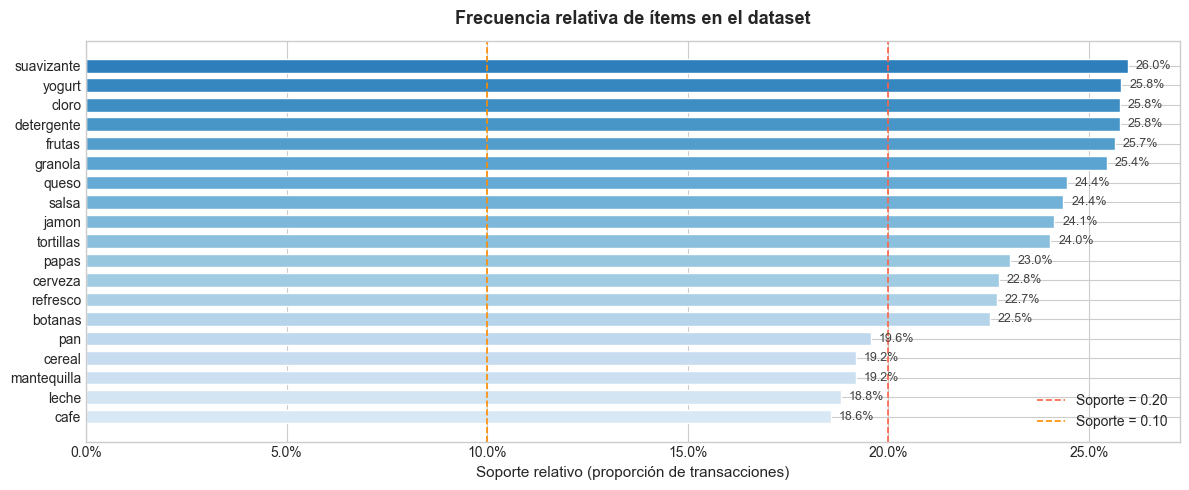

In [9]:
# --- Visualización 1: Frecuencia de ítems ---
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(df_freq)))
bars = ax.barh(df_freq['item'], df_freq['soporte'], color=colors, edgecolor='white', height=0.7)
ax.axvline(x=0.2, color='tomato', linestyle='--', linewidth=1.2, label='Soporte = 0.20')
ax.axvline(x=0.1, color='darkorange', linestyle='--', linewidth=1.2, label='Soporte = 0.10')
ax.set_xlabel('Soporte relativo (proporción de transacciones)', fontsize=11)
ax.set_title('Frecuencia relativa de ítems en el dataset', fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.invert_yaxis()
ax.legend(fontsize=10)
for bar, val in zip(bars, df_freq['soporte']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9, color='#444')
plt.tight_layout()
plt.show()

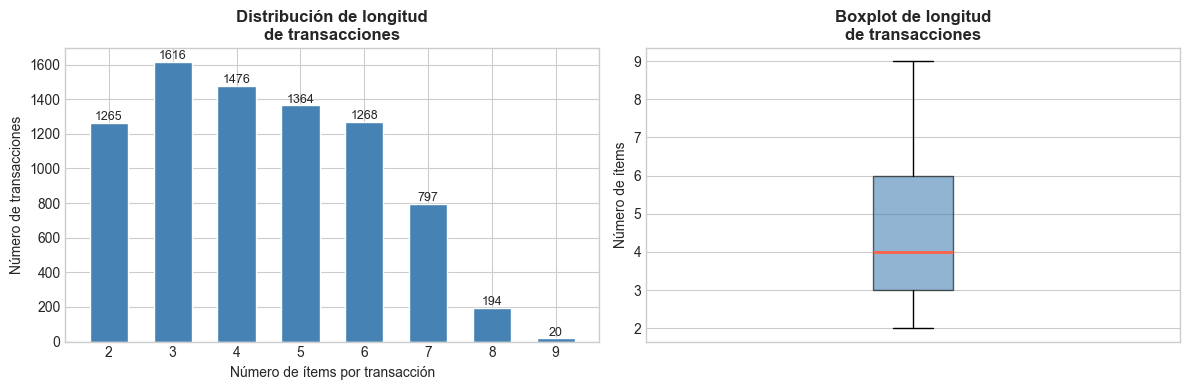

In [10]:
# --- Visualización 2: Distribución de longitud de transacciones ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

len_counts = longitudes.value_counts().sort_index()
axes[0].bar(len_counts.index, len_counts.values, color='steelblue', edgecolor='white', width=0.6)
axes[0].set_xlabel('Número de ítems por transacción')
axes[0].set_ylabel('Número de transacciones')
axes[0].set_title('Distribución de longitud\nde transacciones', fontweight='bold')
for x, y in zip(len_counts.index, len_counts.values):
    axes[0].text(x, y + 15, str(y), ha='center', fontsize=9)

axes[1].boxplot(longitudes, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='tomato', linewidth=2))
axes[1].set_ylabel('Número de ítems')
axes[1].set_title('Boxplot de longitud\nde transacciones', fontweight='bold')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

**Observación:** La distribución de frecuencias es notablemente uniforme (todos los ítems entre ~10% y ~26%). Esto es característico de un dataset sintético y tiene implicaciones directas en el diseño experimental: el soporte mínimo debe explorar rangos que revelen diferencias entre algoritmos, no solo umbrales triviales.

---
## 3. Preprocesamiento

Los algoritmos Apriori y FP-Growth (via `mlxtend`) requieren una **matriz binaria** (one-hot encoding). ECLAT trabaja directamente con listas de transacciones o con la representación vertical (tid-lists). Se preparan ambos formatos.

In [ ]:
# --- Formato de lista de transacciones (para ECLAT) ---
transacciones_lista = df_raw['items_list'].tolist()

# --- Codificación binaria (para Apriori y FP-Growth) ---
te = TransactionEncoder()
te_array = te.fit_transform(transacciones_lista)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print('Formato binario (primeras 5 filas):')
print(f'  Shape: {df_encoded.shape}')
df_encoded.head()

In [ ]:
# --- Densidad de la matriz ---
densidad = df_encoded.values.mean()
print(f'Densidad de la matriz binaria: {densidad:.4f} ({densidad*100:.2f}%)')
print('Interpretación: en promedio, cada celda de la matriz tiene valor True con esta probabilidad.')
print('Una densidad alta favorece FP-Growth sobre Apriori en la práctica.')

---
## 4. Fundamentos teóricos

### 4.1 Conceptos clave

- **Soporte:** $\text{sup}(X) = P(X) = \frac{|\{t \in T : X \subseteq t\}|}{|T|}$
- **Confianza:** $\text{conf}(X \Rightarrow Y) = \frac{\text{sup}(X \cup Y)}{\text{sup}(X)}$
- **Lift:** $\text{lift}(X \Rightarrow Y) = \frac{\text{conf}(X \Rightarrow Y)}{\text{sup}(Y)}$

### 4.2 Comparación conceptual de los algoritmos

| Aspecto | Apriori | FP-Growth | ECLAT |
|---|---|---|---|
| Estructura de datos | Candidatos horizontales | FP-Tree | Listas verticales (tid-lists) |
| Generación de candidatos | Explícita (nivel a nivel) | No genera candidatos | No genera candidatos |
| Acceso a base de datos | Múltiples escaneos | 2 escaneos | 1 escaneo inicial |
| Memoria | Baja | Alta (árbol) | Media-alta (tid-lists) |
| Escalabilidad | Pobre en datasets densos | Buena | Buena en datasets dispersos |
| Propuesto por | Agrawal & Srikant (1994) | Han et al. (2000) | Zaki et al. (1997) |

---
## 5. Implementación de los algoritmos

### 5.1 Parámetros base

In [ ]:
# Parámetros base para la ejecución inicial
MIN_SUPPORT    = 0.10   # 10% de las transacciones
MIN_CONFIDENCE = 0.50   # 50% de confianza
MIN_LIFT       = 1.0    # Solo reglas con lift > 1 (asociación positiva)

### 5.2 Apriori

In [ ]:
# --- Apriori ---
t0 = time.perf_counter()
itemsets_apriori = apriori(
    df_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=None
)
t_apriori = time.perf_counter() - t0

reglas_apriori = association_rules(
    itemsets_apriori,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)
reglas_apriori = reglas_apriori[reglas_apriori['lift'] >= MIN_LIFT]

print(f'Apriori | min_support={MIN_SUPPORT}')
print(f'  Itemsets frecuentes : {len(itemsets_apriori)}')
print(f'  Reglas generadas    : {len(reglas_apriori)}')
print(f'  Tiempo de ejecución : {t_apriori:.4f} s')

reglas_apriori.sort_values('lift', ascending=False).head(10)

### 5.3 FP-Growth

In [ ]:
# --- FP-Growth ---
t0 = time.perf_counter()
itemsets_fpgrowth = fpgrowth(
    df_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=None
)
t_fpgrowth = time.perf_counter() - t0

reglas_fpgrowth = association_rules(
    itemsets_fpgrowth,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)
reglas_fpgrowth = reglas_fpgrowth[reglas_fpgrowth['lift'] >= MIN_LIFT]

print(f'FP-Growth | min_support={MIN_SUPPORT}')
print(f'  Itemsets frecuentes : {len(itemsets_fpgrowth)}')
print(f'  Reglas generadas    : {len(reglas_fpgrowth)}')
print(f'  Tiempo de ejecución : {t_fpgrowth:.4f} s')

reglas_fpgrowth.sort_values('lift', ascending=False).head(10)

### 5.4 ECLAT

In [ ]:
# --- ECLAT ---
# pyECLAT trabaja con un DataFrame de transacciones en formato lista
# Construimos el DataFrame requerido
df_eclat_input = df_raw[['transaction_id', 'items_list']].copy()

t0 = time.perf_counter()
eclat_model = ECLAT(data=df_eclat_input, verbose=False)
indices, soporte_eclat = eclat_model.fit(
    min_support=MIN_SUPPORT,
    min_combination=1,
    max_combination=5,
    separator=' & ',
    verbose=False
)
t_eclat = time.perf_counter() - t0

# Convertir a DataFrame
df_eclat_itemsets = pd.DataFrame(
    list(soporte_eclat.items()),
    columns=['itemset', 'soporte']
).sort_values('soporte', ascending=False)

print(f'ECLAT | min_support={MIN_SUPPORT}')
print(f'  Itemsets frecuentes : {len(df_eclat_itemsets)}')
print(f'  Tiempo de ejecución : {t_eclat:.4f} s')
print('  Nota: pyECLAT retorna itemsets; las reglas deben generarse manualmente desde ellos.')
df_eclat_itemsets.head(10)

In [ ]:
# --- Generar reglas desde ECLAT ---
# ECLAT no genera reglas directamente; las derivamos desde los itemsets frecuentes

def generar_reglas_desde_itemsets(df_itemsets_eclat, min_confidence=0.5, min_lift=1.0, separator=' & '):
    """Genera reglas de asociación a partir de los itemsets de ECLAT."""
    soporte_dict = {frozenset(k.split(separator)): v for k, v in
                    zip(df_itemsets_eclat['itemset'], df_itemsets_eclat['soporte'])}
    reglas = []
    for itemset_str, sup_xy in zip(df_itemsets_eclat['itemset'], df_itemsets_eclat['soporte']):
        items = itemset_str.split(separator)
        if len(items) < 2:
            continue
        for r in range(1, len(items)):
            for antecedente in combinations(items, r):
                consecuente = tuple(i for i in items if i not in antecedente)
                if not consecuente:
                    continue
                sup_x = soporte_dict.get(frozenset(antecedente), None)
                sup_y = soporte_dict.get(frozenset(consecuente), None)
                if sup_x is None or sup_y is None:
                    continue
                confianza = sup_xy / sup_x
                lift = confianza / sup_y
                if confianza >= min_confidence and lift >= min_lift:
                    reglas.append({
                        'antecedentes': set(antecedente),
                        'consecuentes': set(consecuente),
                        'soporte': sup_xy,
                        'confianza': confianza,
                        'lift': lift
                    })
    return pd.DataFrame(reglas).drop_duplicates()

reglas_eclat = generar_reglas_desde_itemsets(
    df_eclat_itemsets, min_confidence=MIN_CONFIDENCE, min_lift=MIN_LIFT
)
print(f'ECLAT | Reglas generadas: {len(reglas_eclat)}')
reglas_eclat.sort_values('lift', ascending=False).head(10)

---
## 6. Diseño experimental

Se evalúan dos ejes de variación:
1. **Soporte mínimo:** bajo (0.05), medio (0.10), alto (0.20)
2. **Tamaño del dataset:** 1,000 / 4,000 / 8,000 transacciones

In [ ]:
SOPORTES  = [0.05, 0.10, 0.15, 0.20]
TAMANOS   = [1000, 4000, 8000]
N_REPS    = 3   # Repeticiones por configuración para estabilizar tiempos

resultados = []

for tamano in TAMANOS:
    # Submuestreo reproducible
    idx = np.random.choice(len(df_raw), size=tamano, replace=False)
    df_sub = df_raw.iloc[idx].reset_index(drop=True)
    trans_sub = df_sub['items_list'].tolist()

    # Codificación binaria para Apriori/FP-Growth
    te_sub = TransactionEncoder()
    df_enc_sub = pd.DataFrame(te_sub.fit_transform(trans_sub), columns=te_sub.columns_)

    for soporte in SOPORTES:
        print(f'  -> n={tamano:,} | soporte={soporte}', end=' ... ')

        # --- Apriori ---
        tiempos_ap = []
        for _ in range(N_REPS):
            t0 = time.perf_counter()
            its = apriori(df_enc_sub, min_support=soporte, use_colnames=True)
            tiempos_ap.append(time.perf_counter() - t0)
        n_its_ap = len(its)
        rls_ap = association_rules(its, metric='confidence', min_threshold=MIN_CONFIDENCE)

        # --- FP-Growth ---
        tiempos_fp = []
        for _ in range(N_REPS):
            t0 = time.perf_counter()
            its_fp = fpgrowth(df_enc_sub, min_support=soporte, use_colnames=True)
            tiempos_fp.append(time.perf_counter() - t0)
        n_its_fp = len(its_fp)
        rls_fp = association_rules(its_fp, metric='confidence', min_threshold=MIN_CONFIDENCE)

        # --- ECLAT ---
        tiempos_ec = []
        for _ in range(N_REPS):
            t0 = time.perf_counter()
            ec_m = ECLAT(data=df_sub[['transaction_id','items_list']], verbose=False)
            _, sup_ec = ec_m.fit(min_support=soporte, min_combination=1, max_combination=5, verbose=False)
            tiempos_ec.append(time.perf_counter() - t0)
        n_its_ec = len(sup_ec)
        df_ec_its = pd.DataFrame(list(sup_ec.items()), columns=['itemset','soporte'])
        rls_ec = generar_reglas_desde_itemsets(df_ec_its, min_confidence=MIN_CONFIDENCE)

        resultados.append({
            'n_transacciones': tamano,
            'min_support': soporte,
            'tiempo_apriori':   np.mean(tiempos_ap),
            'tiempo_fpgrowth':  np.mean(tiempos_fp),
            'tiempo_eclat':     np.mean(tiempos_ec),
            'itemsets_apriori': n_its_ap,
            'itemsets_fpgrowth':n_its_fp,
            'itemsets_eclat':   n_its_ec,
            'reglas_apriori':   len(rls_ap),
            'reglas_fpgrowth':  len(rls_fp),
            'reglas_eclat':     len(rls_ec),
        })
        print('OK')

df_exp = pd.DataFrame(resultados)
print('\nExperimento completado.')
df_exp

---
## 7. Análisis de resultados

### 7.1 Comparación de tiempos de ejecución

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
colores = {'Apriori': '#2166ac', 'FP-Growth': '#1b7837', 'ECLAT': '#d6604d'}

for ax, tamano in zip(axes, TAMANOS):
    sub = df_exp[df_exp['n_transacciones'] == tamano]
    ax.plot(sub['min_support'], sub['tiempo_apriori'],  'o-', color=colores['Apriori'],  label='Apriori',   linewidth=2, markersize=7)
    ax.plot(sub['min_support'], sub['tiempo_fpgrowth'], 's-', color=colores['FP-Growth'],label='FP-Growth', linewidth=2, markersize=7)
    ax.plot(sub['min_support'], sub['tiempo_eclat'],    '^-', color=colores['ECLAT'],     label='ECLAT',     linewidth=2, markersize=7)
    ax.set_title(f'n = {tamano:,} transacciones', fontweight='bold')
    ax.set_xlabel('Soporte mínimo')
    ax.set_ylabel('Tiempo (s)') if tamano == TAMANOS[0] else None
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=9)

plt.suptitle('Tiempo de ejecución por algoritmo, soporte y tamaño del dataset',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Número de itemsets y reglas generadas

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

metricas = [
    ('itemsets_apriori', 'itemsets_fpgrowth', 'itemsets_eclat', 'Itemsets frecuentes'),
    ('reglas_apriori',   'reglas_fpgrowth',   'reglas_eclat',   'Reglas generadas'),
]

for row_idx, (col_ap, col_fp, col_ec, titulo) in enumerate(metricas):
    for col_idx, tamano in enumerate(TAMANOS):
        ax = axes[row_idx][col_idx]
        sub = df_exp[df_exp['n_transacciones'] == tamano]
        ax.plot(sub['min_support'], sub[col_ap], 'o-', color=colores['Apriori'],   label='Apriori',   linewidth=2)
        ax.plot(sub['min_support'], sub[col_fp], 's-', color=colores['FP-Growth'], label='FP-Growth', linewidth=2)
        ax.plot(sub['min_support'], sub[col_ec], '^-', color=colores['ECLAT'],     label='ECLAT',     linewidth=2)
        ax.set_title(f'{titulo}\nn={tamano:,}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Soporte mínimo')
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 7.3 Heatmap de tiempos de ejecución (escalabilidad)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (algo, col) in zip(axes, [('Apriori','tiempo_apriori'),('FP-Growth','tiempo_fpgrowth'),('ECLAT','tiempo_eclat')]):
    pivot = df_exp.pivot(index='n_transacciones', columns='min_support', values=col)
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': 'Tiempo (s)'})
    ax.set_title(algo, fontweight='bold')
    ax.set_xlabel('Soporte mínimo')
    ax.set_ylabel('N transacciones')

plt.suptitle('Mapa de calor: tiempo de ejecución (s)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Interpretación de reglas — análisis con parámetros base

Se utilizan las reglas obtenidas con Apriori (min_support=0.10, min_confidence=0.50) para el análisis interpretativo. FP-Growth produce el mismo conjunto de reglas; ECLAT puede diferir ligeramente por la profundidad máxima configurada.

In [ ]:
# Reglas top por lift
print('=== Top 15 reglas por Lift (Apriori, soporte≥10%, confianza≥50%) ===')
cols_show = ['antecedents','consequents','support','confidence','lift']
top_reglas = reglas_apriori[cols_show].sort_values('lift', ascending=False).head(15)
top_reglas['antecedents'] = top_reglas['antecedents'].apply(lambda x: ', '.join(sorted(x)))
top_reglas['consequents'] = top_reglas['consequents'].apply(lambda x: ', '.join(sorted(x)))
top_reglas.style.format({'support':'{:.3f}', 'confidence':'{:.3f}', 'lift':'{:.3f}'})

In [ ]:
# Visualización: scatter soporte vs confianza coloreado por lift
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    reglas_apriori['support'],
    reglas_apriori['confidence'],
    c=reglas_apriori['lift'],
    cmap='RdYlGn', s=50, alpha=0.7, edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Lift')
ax.set_xlabel('Soporte', fontsize=11)
ax.set_ylabel('Confianza', fontsize=11)
ax.set_title('Reglas de asociación: soporte vs confianza (color = lift)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

In [ ]:
# Reglas con mayor confianza
print('=== Top 10 reglas por Confianza ===')
reglas_apriori[cols_show].sort_values('confidence', ascending=False).head(10)\
    .assign(antecedents=lambda d: d['antecedents'].apply(lambda x: ', '.join(sorted(x))),
            consequents=lambda d: d['consequents'].apply(lambda x: ', '.join(sorted(x))))\
    .style.format({'support':'{:.3f}','confidence':'{:.3f}','lift':'{:.3f}'})

---
## 9. Comparación directa entre algoritmos

In [ ]:
# Resumen con el dataset completo (n=8000) y soporte=0.10
fila_base = df_exp[(df_exp['n_transacciones'] == 8000) & (df_exp['min_support'] == 0.10)]

resumen = pd.DataFrame({
    'Algoritmo':    ['Apriori', 'FP-Growth', 'ECLAT'],
    'Itemsets':     [int(fila_base['itemsets_apriori']), int(fila_base['itemsets_fpgrowth']), int(fila_base['itemsets_eclat'])],
    'Reglas':       [int(fila_base['reglas_apriori']),   int(fila_base['reglas_fpgrowth']),   int(fila_base['reglas_eclat'])],
    'Tiempo (s)':   [round(float(fila_base['tiempo_apriori']),4), round(float(fila_base['tiempo_fpgrowth']),4), round(float(fila_base['tiempo_eclat']),4)],
})
resumen['Velocidad relativa vs Apriori'] = round(float(fila_base['tiempo_apriori']) / resumen['Tiempo (s)'], 2)
resumen

In [ ]:
# Verificación: ¿Apriori y FP-Growth producen los mismos itemsets?
set_ap = set(itemsets_apriori['itemsets'].apply(frozenset))
set_fp = set(itemsets_fpgrowth['itemsets'].apply(frozenset))
print(f'Itemsets exclusivos de Apriori   : {len(set_ap - set_fp)}')
print(f'Itemsets exclusivos de FP-Growth : {len(set_fp - set_ap)}')
print(f'Itemsets en común                : {len(set_ap & set_fp)}')
print()
print('Apriori y FP-Growth producen exactamente los mismos itemsets frecuentes (son matemáticamente equivalentes).')
print('Las diferencias de tiempo reflejan únicamente la eficiencia computacional, no la calidad del resultado.')

---
## 10. Discusión teórica

*(Completar esta sección con tus propias conclusiones basadas en los resultados obtenidos. Las siguientes preguntas guía pueden orientarte):*

1. **Apriori** genera candidatos explícitamente nivel por nivel. ¿Cómo se refleja esto en el tiempo cuando el soporte mínimo es bajo?
2. **FP-Growth** evita la generación de candidatos comprimiendo la base de datos en un árbol. ¿En qué escenarios (densidad, soporte) muestra mayor ventaja?
3. **ECLAT** usa una representación vertical (listas de transacciones por ítem). ¿Por qué esto puede ser ventajoso en datasets dispersos pero costoso en memoria en datasets densos?
4. ¿Qué sucede con el número de reglas cuando se reduce el soporte mínimo? ¿Cómo impacta esto en la interpretabilidad?
5. ¿Qué métrica (soporte, confianza, lift) tiene mayor valor práctico para una decisión de marketing en este dominio?

*(Escribe aquí tu análisis — mínimo 300 palabras para cubrir el criterio 11 de la rúbrica)*

---
## 11. Conclusiones

*(Sintetiza los hallazgos principales. Debe responder directamente al objetivo del trabajo: ¿cuándo usar cada algoritmo? ¿Qué patrones resultaron más relevantes? ¿Qué limitaciones tiene el dataset o la implementación?)*

*(Mínimo 5 puntos concretos basados en tus resultados numéricos — ver criterio 15 de la rúbrica)*

---
## 12. Referencias

- Agrawal, R., & Srikant, R. (1994). Fast algorithms for mining association rules. *Proc. VLDB*, 487–499.
- Han, J., Pei, J., & Yin, Y. (2000). Mining frequent patterns without candidate generation. *ACM SIGMOD Record*, 29(2), 1–12.
- Zaki, M. J., Parthasarathy, S., Ogihara, M., & Li, W. (1997). New algorithms for fast discovery of association rules. *Proc. KDD*, 283–286.
- Raschka, S. (2018). MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack. *Journal of Open Source Software*, 3(24), 638.